# Классификация ориентации текстового кропа (0° / 180°)

Тестовое задание Avito CV internship. Для каждого из 20 000 кропов текста нужно предсказать
`p_180`, вероятность того, что текст перевёрнут. Метрика: 1 − Brier score.

## Подход коротко

1. **Метки из симметрии**: датасету нужны только правильно ориентированные кропы, половину он переворачивает на лету → класс «180°».
2. **Данные**: 60 000 синтетических кропов (`src/synth.py`: PIL-рендер русских/английских слов, артикулов, цен; 181 шрифт с кириллицей; стили «фото» и «скан»; деградации) + 40 000 реальных кропов слов из TextOCR.
3. **Валидация**: 4 000 отложенных реальных кропов TextOCR (+ 4 000 синтетики), детерминированный переворот. Все решения - по ней, не по лидерборду.
4. **Модель**: `TinyOrientNet` с нуля - **285 K параметров, 72 MMAC, 1.1 МБ**, вход grayscale 32×256; длинные строки режутся на окна (ориентация локальна), окна усредняются.
5. **Симметричная TTA**: p = 0.5·(p(x) + 1 − p(rot180(x))), +0.007 на валидации; **калибровка** температурой по валидации.
6. **Self-training на тесте**: уверенные предсказания (p ≤ 0.05 / ≥ 0.95, 75 % теста) добавляются в обучение как правильно ориентированные кропы - адаптация к домену Avito без ручной разметки.

## Результаты

| модель | 1 − Brier, val real (TextOCR, 4 000) | 1 − Brier, test |
|---|---|---|
| v1: TinyOrientNet, 8 эпох (синтетика + TextOCR) | 0.9011 | 0.9557 |
| v1 + 4 эпохи дообучения **без** псевдометок (абляция) | 0.9043 | - |
| **v2 = v1 + 4 эпохи с псевдометками теста, финал** | **0.9062** | **0.9592** |
| v3 = v2 + второй раунд self-training, 6 эпох | 0.9029 | 0.9597 |
| MobileNetV3-Small (927 K параметров), 6 эпох с нуля | 0.8169 | - |

Выводы: валидация на TextOCR пессимистична (короткие слова и логотипы: при aspect < 2 точность 77 %, при aspect ≥ 4 94 %; тест Avito сдвинут к длинным строкам). Абляция: большая часть прироста v1→v2 на валидации это дополнительные эпохи, self-training добавляет +0.002 на валидации и больше на тесте. Второй раунд self-training переобучается на собственные псевдометки (T растёт до 1.3): на тесте v3 на 0.0005 выше v2 (в пределах шума), но по валидации хуже, поэтому финал v2, выбранный по валидации, а не по лидерборду. MobileNetV3-Small без предобучения на 32-px входе хуже и в 3 раза больше.

## Воспроизводимость

* Все seed-ы зафиксированы; версии в `requirements.txt`.
* **Быстрый путь** (точное воспроизведение `submission.csv`): разделы 1 и 8, инференс из `weights/`, ~2 мин на CPU.
* **Полный путь**: разделы 1–7 (генерация данных ≈ 30 мин, обучение ≈ 1 ч на T4); побитовое совпадение на другом GPU не гарантируется.

## Open-source компоненты

TextOCR (CC BY 4.0, через HuggingFace `MiXaiLL76/TextOCR_OCR`); словари `hermitdave/FrequencyWords`; шрифты из Debian-пакетов (OFL / GPL+FE / Apache) в `fonts/`; PyTorch, torchvision, Pillow, OpenCV, fontTools, HF datasets. Внешние API и LLM/VLM не используются, тест вручную не размечался.

## Структура репозитория

```
solution.ipynb      # этот ноутбук
src/synth.py        # генератор синтетики
src/get_real_data.py# загрузка кропов TextOCR
src/data.py         # препроцессинг, аугментации, датасет (переворот = метка)
src/model.py        # TinyOrientNet, MobileNetV3-Small
src/train.py        # обучение, симметричная TTA, температура
src/inference.py    # инференс на тесте, submission, псевдометки
weights/            # чекпоинты v1 / v2 (финал) / v3 + температуры
fonts/, words/      # ресурсы генератора
submission.csv      # = предсказания v2
```

## 1. Данные теста и окружение

In [ ]:
# Запуск из корня репозитория (в Colab: скопировать репозиторий в /content/work и сделать %cd туда).
import os, sys
sys.path.append("src")
os.makedirs("data", exist_ok=True)

# тестовые данные из условия задачи (публичная ссылка Яндекс.Диска)
if not os.path.exists("data/test"):
    import requests, urllib.parse
    public = "https://disk.360.yandex.ru/d/ha0Q70T7ie-0_w"
    api = "https://cloud-api.yandex.net/v1/disk/public/resources/download?public_key=" + urllib.parse.quote(public)
    href = requests.get(api).json()["href"]
    os.system(f'wget -q -O data.zip "{href}" && unzip -q data.zip -d data && rm data.zip')
print(os.listdir("data"))

In [ ]:
# Шрифты уже лежат в fonts/ (скопированы из Debian-пакетов). Если папка пуста: восстановить её так:
from synth import find_fonts, SynthGenerator
if not find_fonts():
    import shutil
    os.system("apt-get -qq install -y fonts-dejavu fonts-liberation fonts-liberation2 fonts-freefont-ttf "
              "fonts-noto-core fonts-roboto fonts-ubuntu fonts-open-sans fonts-croscore fonts-crosextra-carlito "
              "fonts-crosextra-caladea fonts-paratype fonts-lobster fonts-comfortaa fonts-play fonts-lato "
              "fonts-cantarell fonts-droid-fallback > /dev/null")
    os.makedirs("fonts", exist_ok=True)
    for f in find_fonts(dirs=("/usr/share/fonts",)):
        shutil.copy(f, "fonts/")
print(len(SynthGenerator(seed=0).fonts), "fonts")   # 181

## 2. EDA теста

Все кропы уже горизонтальные (вертикальный текст нормализован детектором). Медиана высоты 42 px, 5 % ниже 16 px: вход высотой 32.
Медиана aspect ≈ 5, хвост до 40 (строки сканов): окна фиксированной ширины вместо сжатия. `image_id` в sample_submission без расширения.

In [ ]:
import random
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from data import list_images

test_paths = list_images("data/test/images")
sub_sample = pd.read_csv("data/sample_submission.csv")
print(len(test_paths), "images;", sub_sample.shape, "rows in sample_submission;", sub_sample.image_id.iloc[0])

random.seed(0)
stats = pd.DataFrame([dict(w=Image.open(p).size[0], h=Image.open(p).size[1]) for p in random.sample(test_paths, 3000)])
stats["ar"] = stats.w / stats.h
print(stats.describe(percentiles=[.05, .25, .5, .75, .95]).round(1))

fig, axes = plt.subplots(6, 6, figsize=(18, 9))
for ax, p in zip(axes.flat, random.sample(test_paths, 36)):
    ax.imshow(Image.open(p)); ax.set_title(Image.open(p).size, fontsize=8); ax.axis("off")
plt.tight_layout(); plt.show()

## 3. Обучающие данные

Синтетика генерируется детерминированно по seed; реальные кропы: первые 40 000 подходящих из train-сплита TextOCR
(горизонтальные, h ≥ 10, читаемые). Оба набора содержат только правильно ориентированный текст.

In [ ]:
from synth import generate_to_dir
if not os.path.exists("data/textocr"):
    os.system("python src/get_real_data.py --out data/textocr --n 40000")   # ~10 мин
if not os.path.exists("data/synth"):
    generate_to_dir("data/synth", n=60000, seed=42, workers=2)             # ~25 мин на 2 CPU
print(len(list_images("data/synth")), "synth;", len(list_images("data/textocr")), "textocr")

In [ ]:
# как выглядит синтетика
g = SynthGenerator(seed=0)
fig, ax = plt.subplots(8, 3, figsize=(18, 11))
for a in ax.flat:
    a.imshow(g.sample()); a.axis("off")
plt.tight_layout(); plt.show()

## 4. Базовая модель (v1)

Split: последние 4 000 файлов каждого источника: валидация. `train()` каждую эпоху считает Brier/accuracy на обеих
валидациях и сохраняет лучший чекпоинт по реальной. После обучения: оценка без TTA, с симметричной TTA и с температурой.

In [ ]:
import sys; sys.path.append("src")
from data import list_images
from train import TrainConfig, train, predict_val, combine, fit_temperature, metrics

synth, real = list_images("data/synth"), list_images("data/textocr")
N_VAL = 4000
train_paths = synth[:-N_VAL] + real[:-N_VAL]
val_sets = {"real": real[-N_VAL:], "synth": synth[-N_VAL:]}

cfg = TrainConfig(model="tiny", epochs=8, out_dir="runs/tiny")
model, history = train(cfg, train_paths, val_sets, select_on="real")

lo, lr, y = predict_val(model, val_sets["real"], cfg.H, cfg.W, cfg.seed)
T = fit_temperature(lo, lr, y)
print("no TTA:", metrics(combine(lo, lr, tta=False), y))
print("TTA   :", metrics(combine(lo, lr), y))
print(f"T={T:.2f} TTA+T:", metrics(combine(lo, lr, T), y))

model=tiny params=284,561 train=92,000 val_real=4,000 val_synth=4,000


epoch=1 train_loss=0.6371 time=135.9635 real_brier=0.2768 real_acc=0.5553 synth_brier=0.2829 synth_acc=0.5860
epoch=2 train_loss=0.5095 time=134.6737 real_brier=0.1616 real_acc=0.7582 synth_brier=0.1293 synth_acc=0.8070
epoch=3 train_loss=0.3986 time=134.0747 real_brier=0.1929 real_acc=0.7060 synth_brier=0.2054 synth_acc=0.7190
epoch=4 train_loss=0.3231 time=132.9256 real_brier=0.1229 real_acc=0.8180 synth_brier=0.0618 synth_acc=0.9125
epoch=5 train_loss=0.2794 time=133.4299 real_brier=0.1123 real_acc=0.8330 synth_brier=0.0640 synth_acc=0.9117
epoch=6 train_loss=0.2461 time=132.9286 real_brier=0.1034 real_acc=0.8475 synth_brier=0.0467 synth_acc=0.9343
epoch=7 train_loss=0.2157 time=132.6692 real_brier=0.0997 real_acc=0.8510 synth_brier=0.0447 synth_acc=0.9367
epoch=8 train_loss=0.1994 time=133.3115 real_brier=0.0982 real_acc=0.8545 synth_brier=0.0435 synth_acc=0.9387
no TTA: {'brier': 0.10571356523736881, 'score': 0.8942864347626311, 'logloss': 0.3341563307257547, 'acc': 0.84525}
TTA  

Модель к 8-й эпохе ещё не вышла на плато (train loss и val Brier продолжают падать): это учтено дальше.
Срез ошибок по форме кропа: почти все ошибки: короткие кропы (одно слово / логотип / несколько символов),
которых в тесте Avito заметно меньше, чем в TextOCR.

In [ ]:
import numpy as np
from PIL import Image
p = combine(lo, lr, T)
h = np.array([Image.open(x).size[1] for x in val_sets["real"]])
w = np.array([Image.open(x).size[0] for x in val_sets["real"]])
for lo_h, hi_h in [(0, 16), (16, 24), (24, 40), (40, 80), (80, 10000)]:
    m = (h >= lo_h) & (h < hi_h)
    print(f"h in [{lo_h},{hi_h}): n={m.sum():4d} acc={np.mean((p[m]>0.5)==(y[m]>0.5)):.3f} brier={np.mean((p[m]-y[m])**2):.3f}")
for lo_a, hi_a in [(1, 2), (2, 4), (4, 100)]:
    m = (w/h >= lo_a) & (w/h < hi_a)
    print(f"aspect in [{lo_a},{hi_a}): n={m.sum():4d} acc={np.mean((p[m]>0.5)==(y[m]>0.5)):.3f}")

h in [0,16): n=   0 acc=nan brier=nan
h in [16,24): n=   0 acc=nan brier=nan
h in [24,40): n=1078 acc=0.898 brier=0.073
h in [40,80): n=2175 acc=0.850 brier=0.104
h in [80,10000): n= 747 acc=0.825 brier=0.121
aspect in [1,2): n=1351 acc=0.774
aspect in [2,4): n=2200 acc=0.893
aspect in [4,100): n= 449 acc=0.942


## 5. Инференс на тесте, первая посылка (test 1 − Brier = 0.9557)

In [ ]:
from inference import predict_test, write_submission, build_pseudo_set
df, lo_t, lr_t = predict_test(model, "data/test/images", cfg.H, cfg.W, T=T)
sub = write_submission(df, "data/sample_submission.csv", "submission_v1.csv")
print(sub.p_180.describe())
print("share p>0.5:", (sub.p_180 > 0.5).mean(), " uncertain (0.2<p<0.8):", ((sub.p_180 > 0.2) & (sub.p_180 < 0.8)).mean())

count    2.000000e+04
mean     5.079385e-01
std      4.529982e-01
min      3.595228e-20
25%      7.624309e-04
50%      5.354128e-01
75%      9.995305e-01
max      1.000000e+00
Name: p_180, dtype: float64
share p>0.5: 0.5089  uncertain (0.2<p<0.8): 0.14095


Визуальная проверка (смотреть на тест можно, размечать: нет): уверенные концы шкалы чистые, а среди «неуверенных»
помимо действительно нечитаемых кропов есть вполне читаемые фото-кропы с цветными фонами и стилизованными шрифтами -
домен Avito, которого нет в обучающих данных. Это мотивирует self-training.

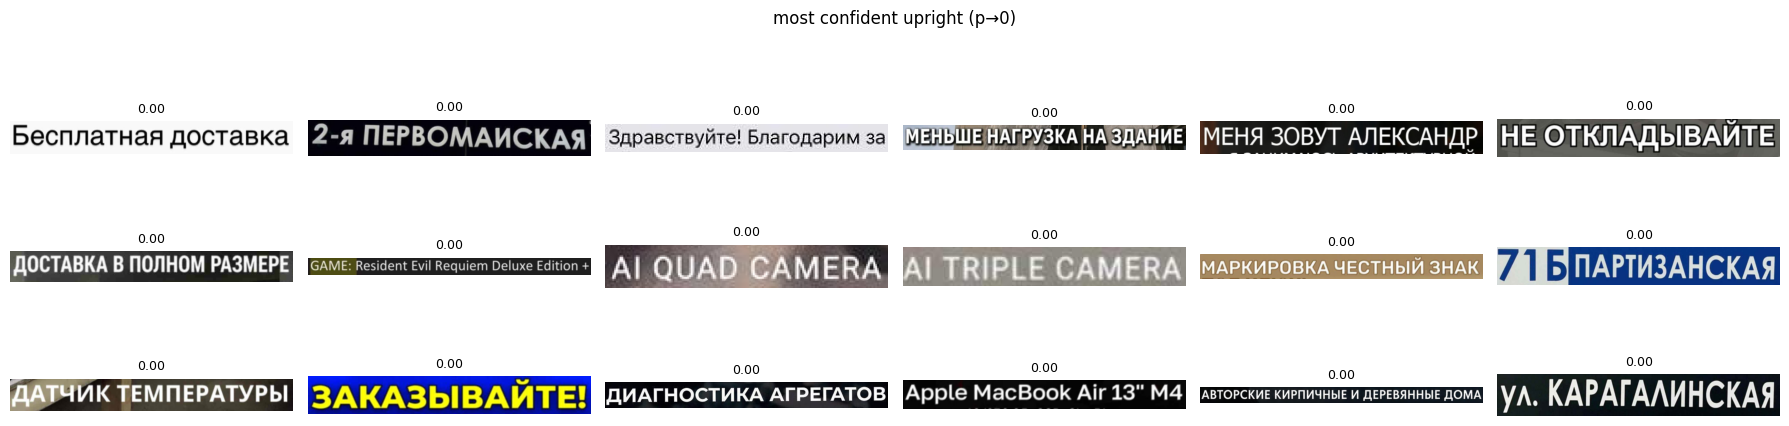

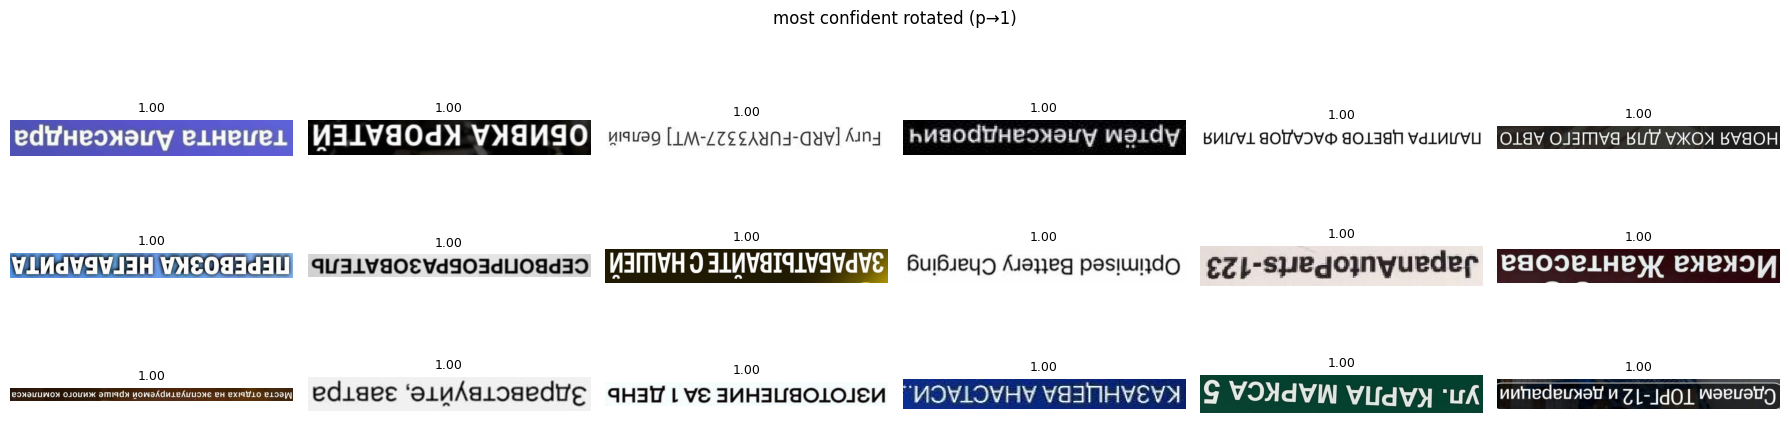

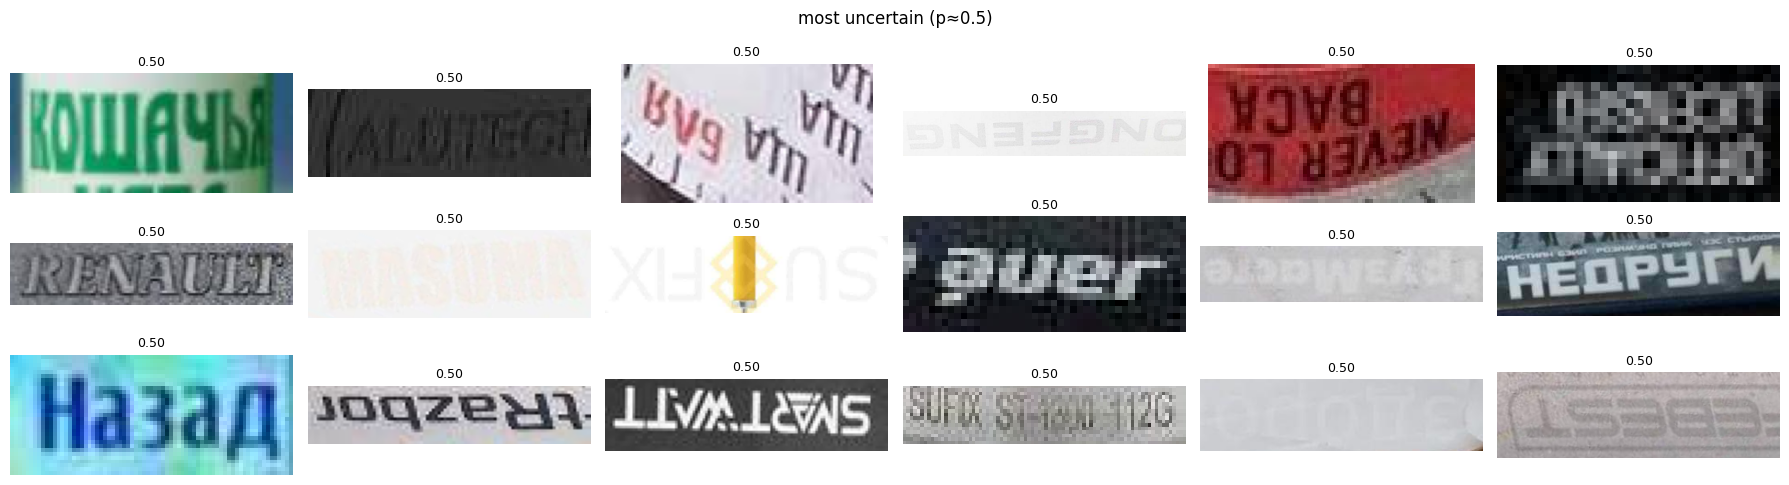

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
def show(ids, title, n=18):
    fig, axes = plt.subplots(3, 6, figsize=(18, 5)); fig.suptitle(title)
    for ax, (i, p) in zip(axes.flat, ids):
        ax.imshow(Image.open(f"data/test/images/{i}.png")); ax.set_title(f"{p:.2f}", fontsize=9); ax.axis("off")
    plt.tight_layout(); plt.show()
s = sub.sort_values("p_180")
show(zip(s.image_id[:18], s.p_180[:18]), "most confident upright (p→0)")
show(zip(s.image_id[-18:], s.p_180[-18:]), "most confident rotated (p→1)")
mid = sub.iloc[(sub.p_180 - 0.5).abs().argsort()[:18]]
show(zip(mid.image_id, mid.p_180), "most uncertain (p≈0.5)")

## 6. Self-training на тесте (v2: финальная модель, test 1 − Brier = 0.9592)

Уверенные предсказания v1 (порог 0.95 с обеих сторон) → 15 000 кропов в правильной ориентации → дообучение v1
на train + псевдометки, 4 эпохи с пониженным LR.

In [ ]:
from train import TrainConfig, train, predict_val, combine, fit_temperature, metrics

# self-training: уверенные предсказания v1 -> в-домене примеры (без ручной разметки)
pseudo = build_pseudo_set(df, "data/test/images", "data/test_pseudo", thr=0.95)

cfg_c = TrainConfig(model="tiny", epochs=4, lr=1e-3, out_dir="runs/tiny_st", init_from="runs/tiny/best.pt")
model_c, history_c = train(cfg_c, train_paths + pseudo, val_sets, select_on="real")

lo_c, lr_c, y = predict_val(model_c, val_sets["real"], cfg_c.H, cfg_c.W, cfg_c.seed)
T_c = fit_temperature(lo_c, lr_c, y)
print("v1 TTA+T:", metrics(combine(lo, lr, T), y))
print(f"v2 T={T_c:.2f} TTA+T:", metrics(combine(lo_c, lr_c, T_c), y))

df_c, _, _ = predict_test(model_c, "data/test/images", cfg_c.H, cfg_c.W, T=T_c)
sub_c = write_submission(df_c, "data/sample_submission.csv", "submission_v2.csv")
print("uncertain share v1 -> v2:", ((sub.p_180>0.2)&(sub.p_180<0.8)).mean(), "->", ((sub_c.p_180>0.2)&(sub_c.p_180<0.8)).mean())
print("v1/v2 disagreement (>0.5 flips):", ((sub.p_180>0.5) != (sub_c.p_180>0.5)).mean())

pseudo set: 14990 of 20000 (thr=0.95); upright=7396 rotated=7594
model=tiny params=284,561 train=106,990 val_real=4,000 val_synth=4,000
epoch=1 train_loss=0.1927 time=171.3411 real_brier=0.1071 real_acc=0.8415 synth_brier=0.0532 synth_acc=0.9275
epoch=2 train_loss=0.1897 time=170.3557 real_brier=0.1004 real_acc=0.8550 synth_brier=0.0473 synth_acc=0.9320
epoch=3 train_loss=0.1669 time=170.9940 real_brier=0.0942 real_acc=0.8600 synth_brier=0.0424 synth_acc=0.9393
epoch=4 train_loss=0.1488 time=170.3272 real_brier=0.0936 real_acc=0.8680 synth_brier=0.0409 synth_acc=0.9435
v1 TTA+T: {'brier': 0.09886829909869987, 'score': 0.9011317009013001, 'logloss': 0.3153356814684726, 'acc': 0.85825}
v2 T=1.10 TTA+T: {'brier': 0.0938440961046519, 'score': 0.9061559038953481, 'logloss': 0.3024468355056832, 'acc': 0.86425}
uncertain share v1 -> v2: 0.14095 -> 0.13
v1/v2 disagreement (>0.5 flips): 0.01925


**Абляция**: то же дообучение без псевдометок: чтобы отделить эффект дополнительных эпох от эффекта псевдометок.

In [ ]:
cfg_c0 = TrainConfig(model="tiny", epochs=4, lr=1e-3, out_dir="runs/tiny_ft", init_from="runs/tiny/best.pt")
model_c0, _ = train(cfg_c0, train_paths, val_sets, select_on="real")
lo_0, lr_0, y = predict_val(model_c0, val_sets["real"], cfg_c0.H, cfg_c0.W, cfg_c0.seed)
print("v1+4ep, no pseudo:", metrics(combine(lo_0, lr_0, fit_temperature(lo_0, lr_0, y)), y))

model=tiny params=284,561 train=92,000 val_real=4,000 val_synth=4,000
epoch=1 train_loss=0.2139 time=139.7445 real_brier=0.1044 real_acc=0.8465 synth_brier=0.0494 synth_acc=0.9305
epoch=2 train_loss=0.2118 time=134.9990 real_brier=0.1038 real_acc=0.8488 synth_brier=0.0475 synth_acc=0.9340
epoch=3 train_loss=0.1846 time=137.3288 real_brier=0.0968 real_acc=0.8592 synth_brier=0.0423 synth_acc=0.9405
epoch=4 train_loss=0.1606 time=137.3633 real_brier=0.0964 real_acc=0.8620 synth_brier=0.0421 synth_acc=0.9407
v1+4ep, no pseudo: {'brier': 0.0957057485168077, 'score': 0.9042942514831923, 'logloss': 0.30683992081070194, 'acc': 0.8625}


## 7. Эксперименты, не вошедшие в финал

**MobileNetV3-Small** (927 K параметров) с нуля на том же наборе: проверка, нужна ли бо́льшая ёмкость.

In [ ]:
cfg_b = TrainConfig(model="mnv3s", epochs=6, out_dir="runs/mnv3s")
model_b, history_b = train(cfg_b, train_paths + pseudo, val_sets, select_on="real")
lo_b, lr_b, y = predict_val(model_b, val_sets["real"], cfg_b.H, cfg_b.W, cfg_b.seed)
print("mnv3s:", metrics(combine(lo_b, lr_b, fit_temperature(lo_b, lr_b, y)), y))

model=mnv3s params=927,297 train=106,990 val_real=4,000 val_synth=4,000
epoch=1 train_loss=0.6669 time=185.2297 real_brier=0.2445 real_acc=0.6525 synth_brier=0.2395 synth_acc=0.6472
epoch=2 train_loss=0.6295 time=178.1911 real_brier=0.2046 real_acc=0.6723 synth_brier=0.2301 synth_acc=0.6398
epoch=3 train_loss=0.6111 time=176.3349 real_brier=0.2060 real_acc=0.6737 synth_brier=0.2105 synth_acc=0.6675
epoch=4 train_loss=0.5781 time=175.8864 real_brier=0.1875 real_acc=0.7077 synth_brier=0.1919 synth_acc=0.7033
epoch=5 train_loss=0.5422 time=176.7101 real_brier=0.1777 real_acc=0.7318 synth_brier=0.1796 synth_acc=0.7195
epoch=6 train_loss=0.5183 time=174.1434 real_brier=0.1767 real_acc=0.7318 synth_brier=0.1737 synth_acc=0.7345
mnv3s: {'brier': 0.18309416633601677, 'score': 0.8169058336639832, 'logloss': 0.5403788910056634, 'acc': 0.71525}


**Второй раунд self-training** (псевдометки от v2, 6 эпох). Валидация ухудшается после 4-й эпохи, температура растёт
до 1.3: модель начинает подгоняться под собственные псевдометки. По правилу «выбор по валидации» финалом остаётся v2.

In [ ]:
# второй раунд self-training: псевдометки от v2
pseudo2 = build_pseudo_set(df_c, "data/test/images", "data/test_pseudo2", thr=0.95)
cfg_f = TrainConfig(model="tiny", epochs=6, lr=1e-3, out_dir="runs/tiny_final", init_from="runs/tiny_st/best.pt")
model_f, history_f = train(cfg_f, train_paths + pseudo2, val_sets, select_on="real")
lo_f, lr_f, y = predict_val(model_f, val_sets["real"], cfg_f.H, cfg_f.W, cfg_f.seed)
T_f = fit_temperature(lo_f, lr_f, y)
print(f"v3 T={T_f:.2f}:", metrics(combine(lo_f, lr_f, T_f), y))
df_f, _, _ = predict_test(model_f, "data/test/images", cfg_f.H, cfg_f.W, T=T_f)
sub_f = write_submission(df_f, "data/sample_submission.csv", "submission_v3.csv")

pseudo set: 15375 of 20000 (thr=0.95); upright=7583 rotated=7792
model=tiny params=284,561 train=107,375 val_real=4,000 val_synth=4,000
epoch=1 train_loss=0.1591 time=172.7783 real_brier=0.1169 real_acc=0.8293 synth_brier=0.0721 synth_acc=0.9055
epoch=2 train_loss=0.1703 time=176.4533 real_brier=0.1073 real_acc=0.8430 synth_brier=0.0545 synth_acc=0.9245
epoch=3 train_loss=0.1606 time=173.7232 real_brier=0.1008 real_acc=0.8558 synth_brier=0.0501 synth_acc=0.9330
epoch=4 train_loss=0.1379 time=174.0112 real_brier=0.0972 real_acc=0.8590 synth_brier=0.0423 synth_acc=0.9407
epoch=5 train_loss=0.1196 time=177.6753 real_brier=0.0975 real_acc=0.8640 synth_brier=0.0403 synth_acc=0.9467
epoch=6 train_loss=0.1073 time=173.7231 real_brier=0.0985 real_acc=0.8642 synth_brier=0.0406 synth_acc=0.9447
v3 T=1.30: {'brier': 0.09708709179848014, 'score': 0.9029129082015198, 'logloss': 0.3120198775274739, 'acc': 0.85725}


In [ ]:
print("T =", T, "T_c =", T_c, "T_f =", T_f)

T = 0.95 T_c = 1.1 T_f = 1.3


## 8. Производительность и воспроизведение финальной посылки

In [ ]:
# производительность: параметры, MAC, латентность на CPU
import time, torch
from model import build_model, count_params
m = build_model("tiny").eval()
macs = 0
def hook(mod, inp, out):
    global macs
    if isinstance(mod, torch.nn.Conv2d):
        macs += out.numel() // out.shape[0] * mod.in_channels // mod.groups * mod.kernel_size[0] * mod.kernel_size[1]
    elif isinstance(mod, torch.nn.Linear):
        macs += mod.in_features * mod.out_features
hs = [mod.register_forward_hook(hook) for mod in m.modules() if isinstance(mod, (torch.nn.Conv2d, torch.nn.Linear))]
with torch.no_grad(): m(torch.zeros(1, 1, 32, 256))
for h_ in hs: h_.remove()
print(f"params={count_params(m):,}  MACs={macs/1e6:.1f}M  weights={count_params(m)*4/1024:.0f} KB (fp32)")
torch.set_num_threads(1)
with torch.no_grad():
    for bs in [1, 64]:
        x = torch.zeros(bs, 1, 32, 256)
        for _ in range(3): m(x)
        t = time.perf_counter(); n = 20
        for _ in range(n): m(x)
        dt = (time.perf_counter() - t) / n
        print(f"CPU 1 thread, batch={bs}: {dt*1000:.2f} ms/batch = {dt/bs*1000:.3f} ms/crop")

params=284,561  MACs=72.0M  weights=1112 KB (fp32)
CPU 1 thread, batch=1: 7.97 ms/batch = 7.974 ms/crop
CPU 1 thread, batch=64: 375.45 ms/batch = 5.866 ms/crop


Симметричная TTA удваивает стоимость инференса (плюс до 3 окон для длинных строк); без TTA модель даёт 0.894 вместо 0.901
на валидации: компромисс можно выбирать под нагрузку.

Финальная посылка `submission.csv`: предсказания v2 с TTA и T = 1.10. Ячейка ниже воспроизводит её из приложенных весов
(`weights/v2_tiny_selftrain.pt`), не требуя обучения.

In [ ]:
import json
from train import load_model
from inference import predict_test, write_submission

model_final, cfg_final = load_model("weights/v2_tiny_selftrain.pt")
T_final = json.load(open("weights/temperatures.json"))["v2_tiny_selftrain"]
df_final, _, _ = predict_test(model_final, "data/test/images", cfg_final.H, cfg_final.W, T=T_final)
final = write_submission(df_final, "data/sample_submission.csv", "submission.csv")
print(final.head(), final.shape, sep="\n")